In [27]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('display.max_columns', 1500)

In [28]:
df = pd.read_csv('../data/raw/Photo.csv')

In [29]:
epi_tool = df[df["Tool ID"] == 0].copy()

## Tool Parameters
Input 1 range: 100-140, aggression: 8
Input 2 range: 4-6, aggression: 8
Output range: 5-10

In [30]:
epi_tool.head(10)

,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed
0,Photo,0,2,447,452,102.685412,4.005478,5.134470,False
1,Photo,0,1,539,545,105.825551,4.071414,5.299028,False
3,Photo,0,2,743,748,109.211563,4.091448,5.475289,False
4,Photo,0,4,760,765,112.354279,4.127953,5.645659,False
5,Photo,0,5,987,993,114.218227,4.133880,5.743667,False
6,Photo,0,8,997,1003,116.385228,4.180465,5.872507,False
7,Photo,0,7,1022,1027,117.929234,4.212472,5.966652,False
8,Photo,0,6,1043,1049,131.809477,4.277759,6.739491,False
9,Photo,0,1,1171,1177,135.348377,4.283553,6.932909,False
10,Photo,0,9,1266,1271,138.966509,4.293204,7.134124,False


## Holistic View of Data

In [31]:
epi_tool.describe()

,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output
count,22763.0,22763.000000,2.276300e+04,2.276300e+04,22763.000000,22763.000000,22763.000000
mean,0.0,7796.286298,7.849837e+05,7.849892e+05,139.234973,4.495138,7.441398
std,0.0,4499.810786,4.556716e+05,4.556716e+05,22.122687,0.288510,1.510246
min,0.0,1.000000,4.470000e+02,4.520000e+02,99.480627,3.961627,4.975672
25%,0.0,3898.500000,3.911505e+05,3.911565e+05,120.169267,4.249453,6.110673
50%,0.0,7804.000000,7.822270e+05,7.822320e+05,139.161903,4.488876,7.326759
75%,0.0,11681.000000,1.181423e+06,1.181428e+06,158.110996,4.725960,8.712836
max,0.0,15601.000000,1.576783e+06,1.576788e+06,191.907405,5.340379,10.730744


The average of the inputs seem to be within the ranges of the tool.

## Univariate Distributions

Looking at Inputs first, ensuring monotonic drift:

Text(0, 0.5, 'Runs')

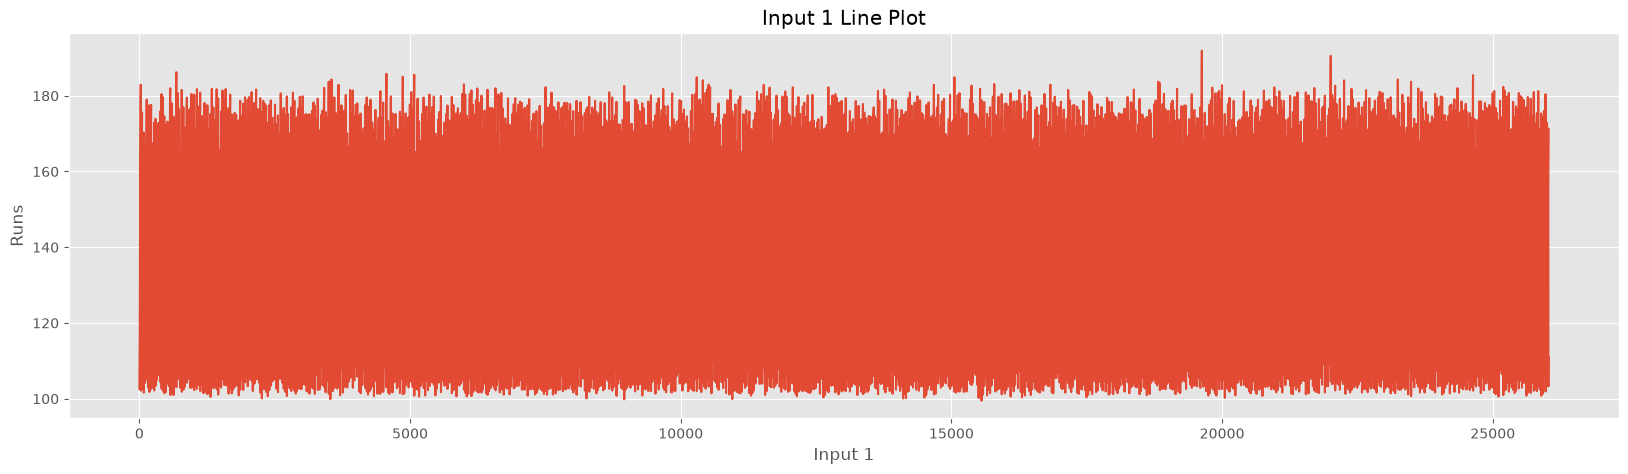

In [32]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 1'].plot(kind='line', title="Input 1 Line Plot")
line.set_xlabel('Input 1')
line.set_ylabel('Runs')

Text(0, 0.5, 'Runs')

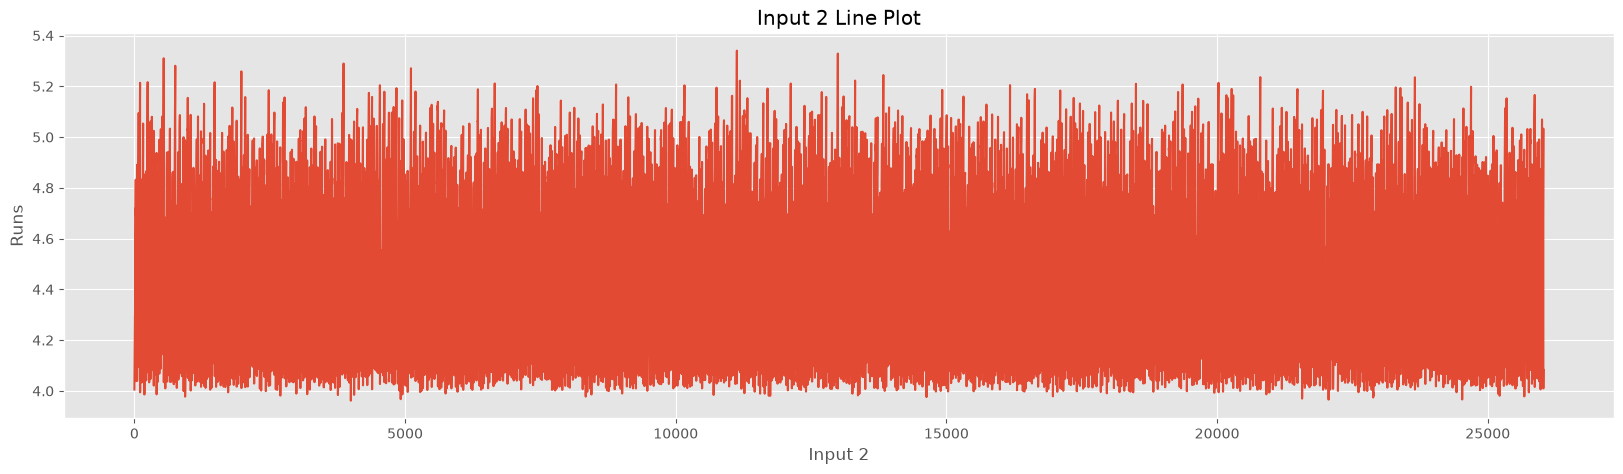

In [33]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 2'].plot(kind='line', title="Input 2 Line Plot")
line.set_xlabel('Input 2')
line.set_ylabel('Runs')

Both are showing what would be expected from degradation-driven inputs. Both show monotonic drift, although the noise in Input 2 seems to have a greater relative effect since Input 2 is much smaller in terms of magnitude.

Now an analysis of output

Text(0, 0.5, 'Runs')

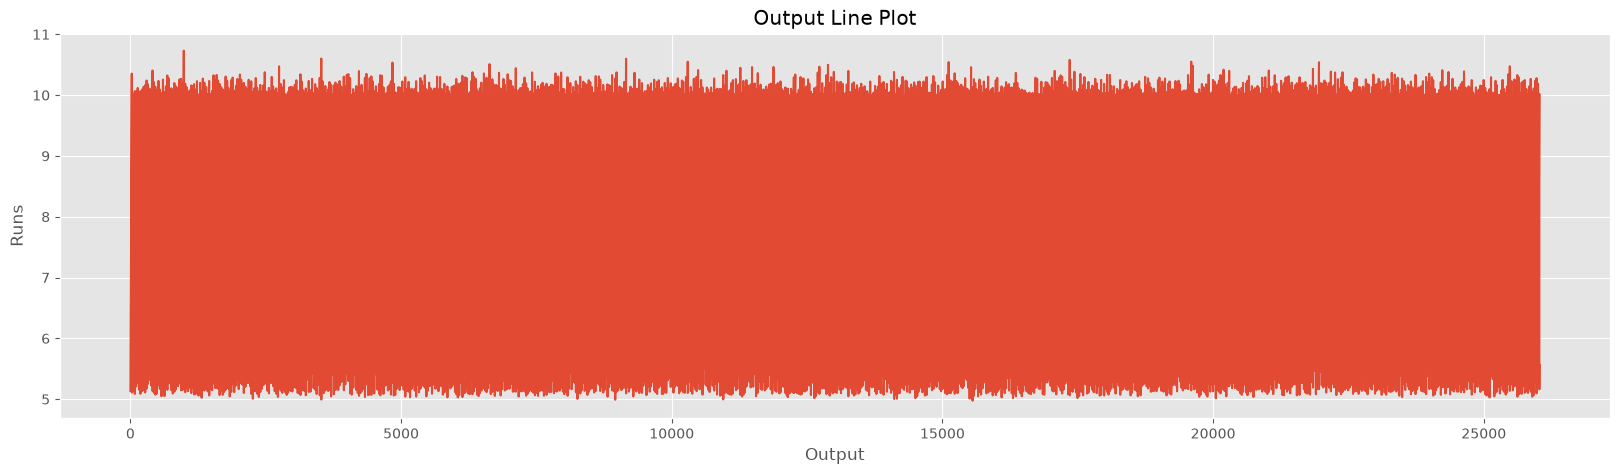

In [34]:
plt.figure(figsize=(20, 5))
line = epi_tool['Output'].plot(kind='line', title="Output Line Plot")
line.set_xlabel('Output')
line.set_ylabel('Runs')

<Axes: >

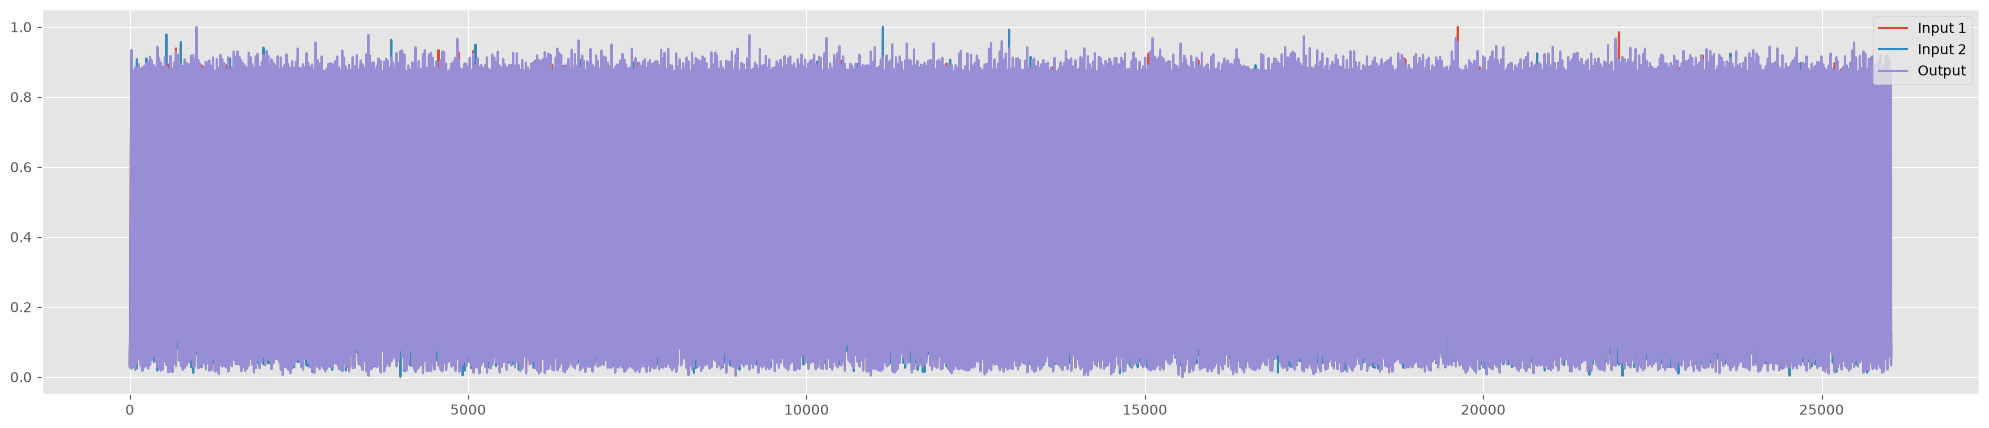

In [35]:
df_norm = (epi_tool[['Input 1', 'Input 2', 'Output']] - epi_tool[['Input 1', 'Input 2', 'Output']].min()) / \
          (epi_tool[['Input 1', 'Input 2', 'Output']].max() - epi_tool[['Input 1', 'Input 2', 'Output']].min())
df_norm.plot(kind='line',figsize=(25, 5))


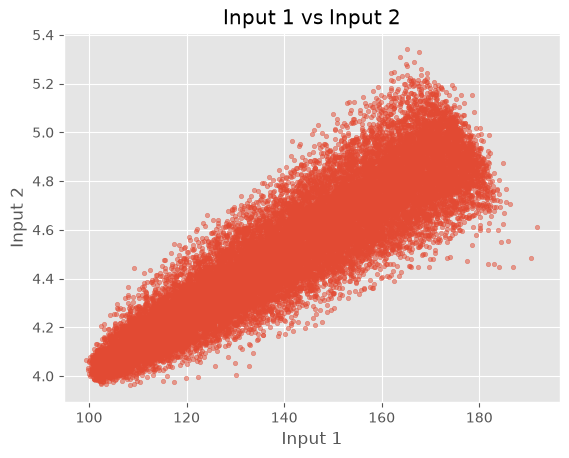

In [36]:
plt.scatter(epi_tool['Input 1'], epi_tool['Input 2'], alpha=0.5, s=10)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Input 1 vs Input 2')
plt.show()

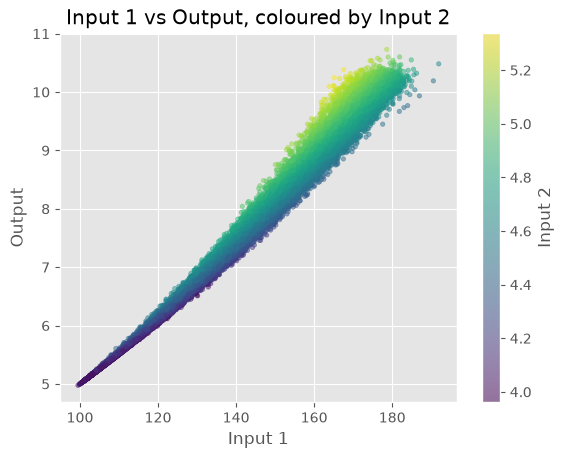

In [37]:
scatter = plt.scatter(epi_tool['Input 1'], epi_tool['Output'], c=epi_tool['Input 2'], alpha=0.5, s=10, cmap='viridis')
plt.xlabel('Input 1')
plt.ylabel('Output')
plt.colorbar(scatter, label='Input 2')
plt.title('Input 1 vs Output, coloured by Input 2')
plt.show()

In [38]:
epi_tool[['Input 1', 'Input 2', 'Output']].corr()

,Input 1,Input 2,Output
Input 1,1.000000,0.910218,0.993238
Input 2,0.910218,1.000000,0.942184
Output,0.993238,0.942184,1.000000


In [39]:
epi_tool['Input 2'].pow(2).corr(epi_tool['Output'])

np.float64(0.9407764519725097)

As expected, Input 1 has a strong linear relationship with Output. Within the formula, Input 1 has a direct linear term in the formula used. Surprisingly, Input 2 also has a strong pairwise correlation (as input 2 is a non linear term in the equation),  potentially explained by Input 2 having a much narrower range, so its quadratic contribution does not have enough room to show its non-linearity. A look into the pearson correlation between Input 2 squared and output shows near enough the same value, confirming that the range is too narrow to see meaningful non-linear trends.

## Calculating RUL and observing individual variable effects on RUL

In [40]:
epi_tool["Shifted"] = epi_tool["Failed"].shift(periods=1, fill_value= False)
epi_tool["Cycle Group"] = epi_tool["Shifted"].cumsum()
epi_tool["Forward"] = epi_tool.groupby(["Cycle Group"]).cumcount()
epi_tool["Cycle Size"] = epi_tool.groupby("Cycle Group")["Failed"].transform("size")
epi_tool["RUL"] = epi_tool["Cycle Size"] - epi_tool["Forward"] - 1
epi_tool = epi_tool.drop(columns=['Shifted','Cycle Size','Forward'])
last_cycle = epi_tool["Cycle Group"].max()
last_cycle_rows = epi_tool["Cycle Group"] == last_cycle #cycle group as a series of boolean values
last_cycle_has_breach = epi_tool.loc[last_cycle_rows, 'Failed'].any()
if last_cycle_has_breach == False:
    epi_tool = epi_tool[~last_cycle_rows]



<Axes: xlabel='RUL', ylabel='Input 1'>

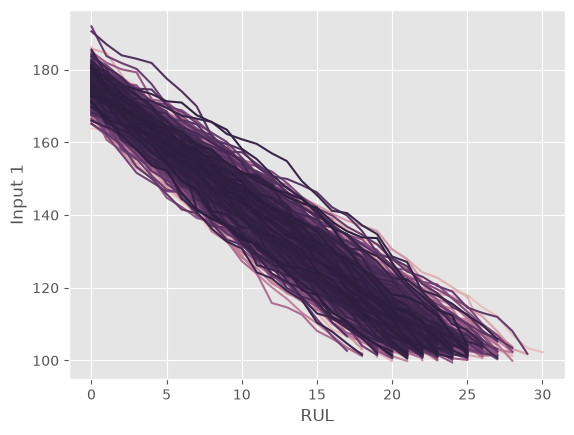

In [41]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Input 2'>

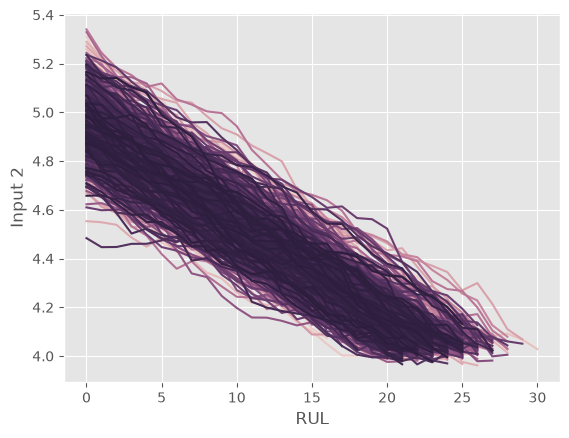

In [42]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 2", hue="Cycle Group", legend = False)

In [43]:
epi_tool["Rolling Mean 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(5).mean().reset_index(level=0,drop=True)
epi_tool["Rolling Mean 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(5).mean().reset_index(level=0,drop=True)


<Axes: xlabel='RUL', ylabel='Rolling Mean 1'>

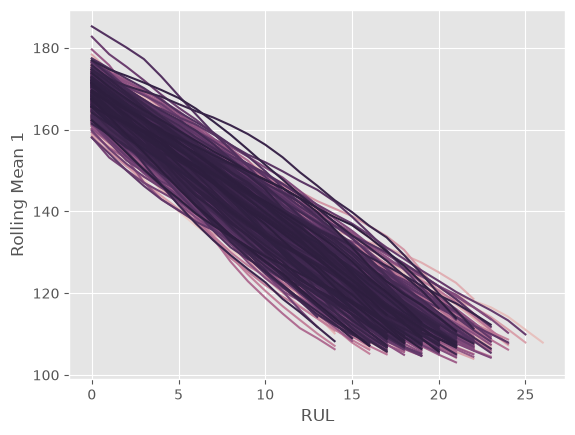

In [44]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Mean 2'>

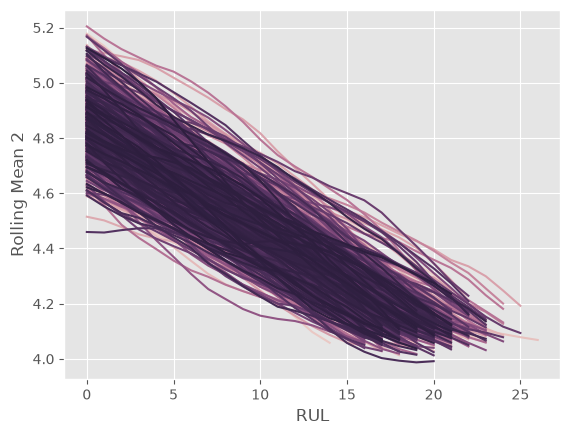

In [45]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 2", hue="Cycle Group", legend = False)

Rolling means have smoothed out the cycles, but no major changes compared to raw values

<Axes: xlabel='RUL', ylabel='Rolling Std 1'>

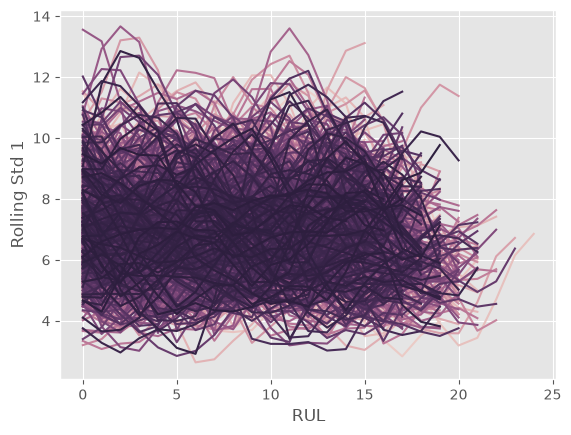

In [46]:
epi_tool["Rolling Std 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(7).std().reset_index(level=0,drop=True)
epi_tool["Rolling Std 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(7).std().reset_index(level=0,drop=True)
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 2'>

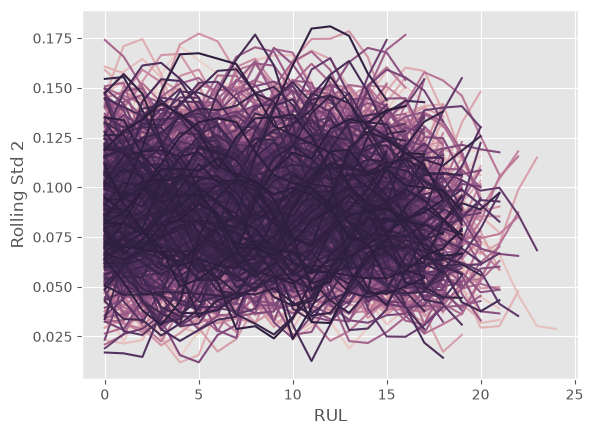

In [47]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 2", hue="Cycle Group", legend = False)

In [48]:
n = 5
epi_tool["Shift1"] = epi_tool.groupby("Cycle Group")["Rolling Mean 1"].shift(n)
epi_tool["RoC1"] = epi_tool["Rolling Mean 1"] - epi_tool["Shift1"]

epi_tool["Shift2"] = epi_tool.groupby("Cycle Group")["Rolling Mean 2"].shift(n)
epi_tool["RoC2"] = epi_tool["Rolling Mean 2"] - epi_tool["Shift2"]

<Axes: xlabel='RUL', ylabel='RoC1'>

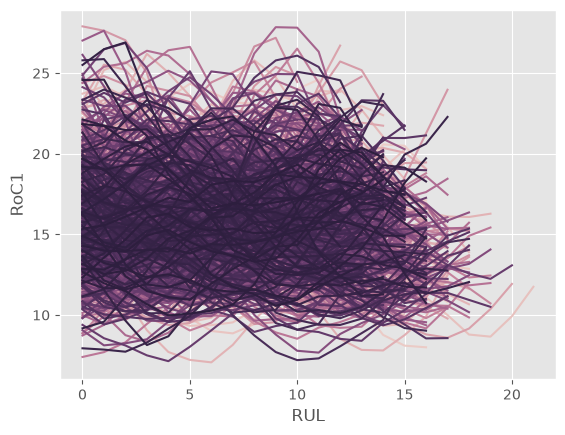

In [49]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='RoC2'>

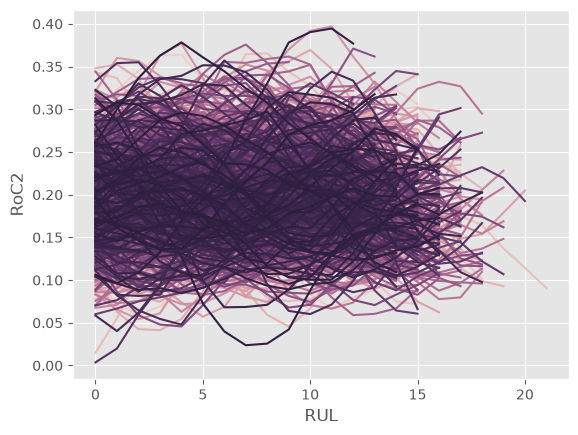

In [50]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC2", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Output'>

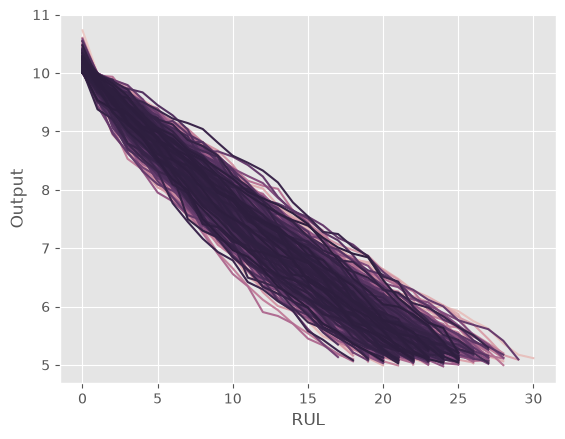

In [51]:
sns.lineplot(data=epi_tool, x="RUL", y="Output", hue="Cycle Group", legend=False)